**Importing the data** 


In [19]:
import torch 										# pyright: ignore[reportMissingImports]
import torchvision 									# pyright: ignore[reportMissingImports]
from torchvision import datasets, transforms 		# pyright: ignore[reportMissingImports]
from torch.utils.data import DataLoader 			# pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt 					# pyright: ignore[reportMissingModuleSource, reportMissingImports]

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device) 

Using: cuda


In [18]:
transform = transforms.Compose([
    transforms.ToTensor(),                
    transforms.Normalize((0.5,), (0.5,)), 
])

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

img, label = train_data[0]
print("Number of images:", len(train_data))
print("Image shape:", img.shape)                                 
print("Pixel range:", round(img.min().item(), 2), "to", round(img.max().item(), 2)) 
print(label)

Number of images: 60000
Image shape: torch.Size([1, 28, 28])
Pixel range: -1.0 to 1.0
5


In [10]:
loader = DataLoader(train_data, batch_size=64, shuffle=True)
batch, labels = next(iter(loader))
print("Batch shape:", batch.shape)  

Batch shape: torch.Size([64, 1, 28, 28])


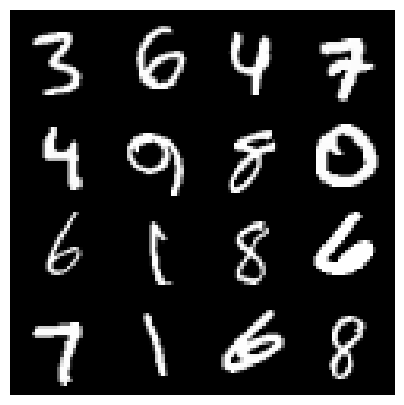

In [11]:
def show_grid(images, n=16):
    images = (images[:n] + 1) / 2       
    grid = torchvision.utils.make_grid(images, nrow=4)
    plt.figure(figsize=(5, 5))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.show()

show_grid(batch)